In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
%matplotlib inline 
np.set_printoptions(precision=4, suppress=True) 

In [26]:
class Lattice:
    def __init__(self, a1, a2):
        self.a1 = np.array(a1)
        self.a2 = np.array(a2)
        
    def get_reciprocal_lattice(self):
        area = np.linalg.norm(np.cross(np.append(self.a1, 0), np.append(self.a2, 0)))
        b1 = 2 * np.pi * np.array([self.a2[1], -self.a2[0]]) / area
        b2 = 2 * np.pi * np.array([-self.a1[1], self.a1[0]]) / area
        
        return b1, b2

In [27]:
class TightBindingSolver:
    def __init__(self, lattice):
        self.lattice = lattice

    def hamiltonian(self, kx, ky, t=1.0):
        #dot product
        k_dot_a1 = kx * self.lattice.a1[0] + ky * self.lattice.a1[1]
        k_dot_a2 = kx * self.lattice.a2[0] + ky * self.lattice.a2[1]
        

        f_k = -t * (1 + np.exp(1j * k_dot_a1) + np.exp(1j * k_dot_a2))
        
        H = np.array([
            [0, f_k],
            [np.conj(f_k), 0]
        ], dtype=complex)
        
        return H

    def solve_band_structure(self, k_path):
        energies = []
        for k in k_path:
            H = self.hamiltonian(k[0], k[1])
            evals, evecs = np.linalg.eigh(H)
            energies.append(evals)
            
        return np.array(energies)

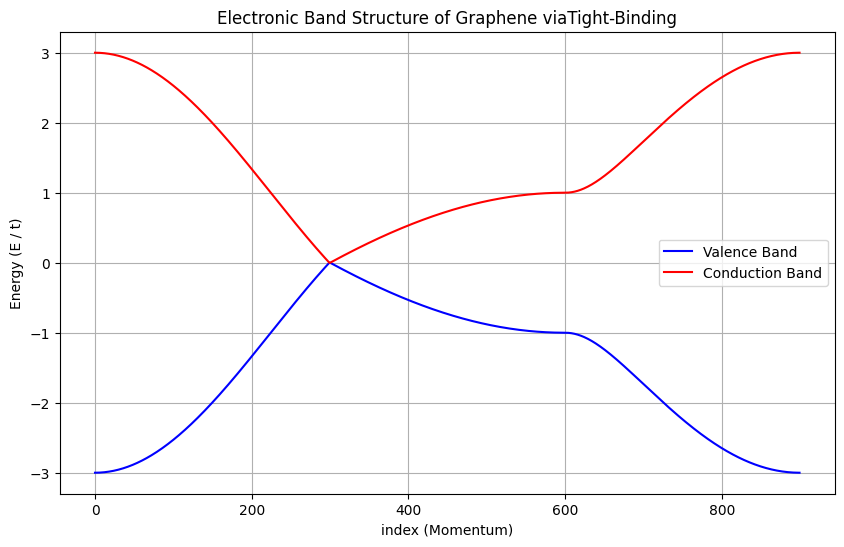

In [ ]:
graphene_lattice = Lattice(
    a1=[3/2, np.sqrt(3)/2], 
    a2=[3/2, -np.sqrt(3)/2]
)

solver = TightBindingSolver(graphene_lattice)
num_points = 300
k_path = []
b1,b2=graphene_lattice.get_reciprocal_lattice()
# G to K
k_vals1x = np.linspace(0, (2*b1[0]+b2[0])/3, num_points)
k_vals1y = np.linspace(0, (2*b1[1]+b2[1])/3, num_points)
for kx,ky in zip (k_vals1x,k_vals1y):
    k_path.append([kx, ky])
# K to M
k_vals2x=np.linspace((2*b1[0]+b2[0])/3,(b1[0]+b2[0])/2,num_points)
k_vals2y=np.linspace((2*b1[1]+b2[1])/3,(b1[1]+b2[1])/2,num_points)

for kx,ky in zip (k_vals2x,k_vals2y):
    k_path.append([kx, ky])
k_vals3x=np.linspace((b1[0]+b2[0])/2,0,num_points)
k_vals3y=np.linspace((b1[1]+b2[1])/2,0,num_points)
# M to G
for kx,ky in zip (k_vals3x,k_vals3y):
    k_path.append([kx, ky])

bands = solver.solve_band_structure(k_path)


plt.figure(figsize=(10, 6))
plt.plot(bands[:, 0], 'b-', label='Valence Band') 
plt.plot(bands[:, 1], 'r-', label='Conduction Band') 
plt.title("Electronic Band Structure of Graphene viaTight-Binding")
plt.ylabel("Energy (E / t)")
plt.xlabel("index (Momentum)")
plt.legend()
plt.grid(True)
plt.show()